In [1]:
import sys
sys.path.insert(0, '../')
from lib import *
DEBUG = False;


In [3]:
WEEK="APSAIA_VIS_2";

path="/pc/choozdsk01/users/romeo/LAB/"+WEEK+"/joython/"
Runs=open_runs_table("../macros/"+WEEK+".xlsx")
Calib_run=Runs[(Runs["Type"]=="Calibration")].iloc[2] #2nd calib run, middle voltage 

av_wvfs={}

for run in [37,38,39]:
    print("Run",run)
    Run_props=Runs.iloc[0]
    run_path=path+"run"+str(run).zfill(2)+"/";

    compress=False
    
    
    for ch in [5]:
        ADC=open_run_var(run_path,"RawADC",[ch],compressed=True)
        Pedestal_vars_SW=open_run_var(run_path,"Pedestal_vars",[ch],compressed=compress)
        
        ADC=do_run_things((ADC,Pedestal_vars_SW,Run_props["Polarity"]),substract_Pedestal)
        wvf_avg=np.mean(ADC[ch],axis=0) 
        av_wvfs[run]=wvf_avg


Run 37
----------
Doing:  substract_Pedestal  on channel: 5
Run 38
----------
Doing:  substract_Pedestal  on channel: 5
Run 39
----------
Doing:  substract_Pedestal  on channel: 5


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …
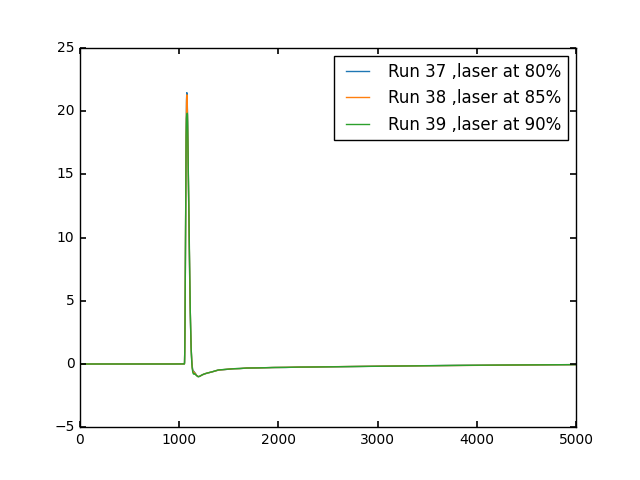

In [4]:
%matplotlib widget

laser=["80%","85%","90%"]

# for wvf, in av_wvfs:
for wvf,intensity in zip(av_wvfs, laser):
    plt.plot(av_wvfs[wvf]/abs(min(av_wvfs[wvf])),label="Run "+str(wvf)+" ,laser at "+intensity)

plt.legend()
# plt.ylim(-0.1,1.1)